# Preprocessing

In [ ]:
import numpy as np

In [ ]:
# do not run because it breaks how numpy arrays will work in all python imports
class CustomArray(np.ndarray):
    @property
    def T(self):
        if self.ndim == 1: return self[:, np.newaxis]
        return super().T

def custom_array(input_array):
    return np.asarray(input_array).view(CustomArray)
arr = custom_array

# Linear Regression

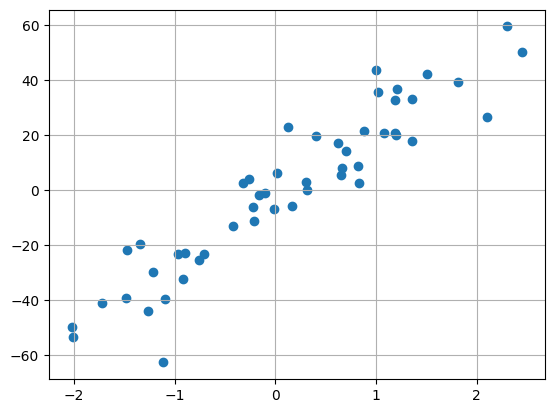

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

X, y = make_regression(n_samples=50, n_features=1, noise=10)
fig, ax = plt.subplots()
ax.scatter(X, y)
ax.grid()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
assert isinstance(X, np.ndarray)

In [ ]:
class ShitLinearRegression:

    def __init__(self):
        self.is_fitted = False
    
    @staticmethod
    def h(xⁱ: np.array, θ: np.array) -> float:
        return xⁱ.T @ θ
    
    @staticmethod
    def add_design_matrix_intercept(X: np.array) -> np.array:
        m = X.shape[0]
        intercept = np.ones((m, 1))
        return np.hstack((intercept, X))
    
    def check_fit(self):
        if not self.is_fitted:
            raise ValueError('Model must be fitted before doing that.')

    def iterative_batch_gd(self, X: np.array, y_train: np.array, α: float = 0.05, n_iters: int = 100) -> None:
        m = X.shape[0]
        n = X.shape[1] - 1
        θ = np.zeros((n+1, 1))

        for k in range(n_iters):

            for j in range(n+1):

                gradient = 0
                for i in range(m):
                    xⁱ = X[i].reshape(-1, 1) # Tranpose row
                    gradient += (self.h(xⁱ, θ) - y_train[i]) * xⁱ[j]
                
                θ[j] = θ[j] - α * gradient
        
        self.θ = θ

    def iterative_stochastic_gd(self):
        raise NotImplementedError

    def matrix_batch_gd(self, X: np.array, y: np.array):
        self.θ = np.linalg.inv(X.T @ X) @ (X.T @ y)

    def fit(self, X_train: np.array, y_train: np.array, gd='auto'):
        self.is_fitted = True

        X_train = self.add_design_matrix_intercept(X_train)
        y_train = y_train


        gd_algorithms = {'iterative_batch': self.iterative_batch_gd,
                         'iterative_stochastic': self.iterative_stochastic_gd,
                         'matrix_batch': self.matrix_batch_gd}
        if gd == 'auto':
            if X_train.shape[0] <= 100:
                gd = 'matrix_batch'
            else:
                gd = 'iterative_stochastic'
        gd_algorithms.get(gd)(X_train, y_train)
    
    def predict(self, X_test):
        self.check_fit()
        
        X_test = self.add_design_matrix_intercept(X_test)
        return X_test @ self.θ


    def is_overfitted(self):
        self.check_fit()
        pass

model = ShitLinearRegression()
model.fit(X, y_train)
predictions = model.predict(X_test).reshape(1, -1)[0]
print(mean_absolute_percentage_error(y_test, predictions))

model = LinearRegression()
model.fit(X, y_train)
predictions = model.predict(X_test)
print(mean_absolute_percentage_error(y_test, predictions))

[ 1.56657872 61.66349213]
0.675324062717508
0.6753240627175081


# Neural Network

## Numpy

In [ ]:
# Numpy, no autograd

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

X, y = make_regression(n_samples=50, n_features=1, noise=10)
y = y.reshape(-1, 1)  # Ensure y is a column vector

"""
fig, ax = plt.subplots()
ax.scatter(X, y)
ax.grid()
plt.show()
"""

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

from abc import ABC, abstractmethod
from typing import Callable
np.random.seed(42) # so I get NaN values more consistently when overflows occur

class Layer(ABC):
    @abstractmethod
    def feedforward(self, input):
        pass

    @abstractmethod
    def backpropagation(self, grad_output):
        pass

class Flatten(Layer):
    def feedforward(self, input):
        self.input_shape = input.shape
        return input.flatten()

    def backpropagation(self, grad_output):
        return grad_output.reshape(self.input_shape)

class DenseLinear(Layer):
    def __init__(self, fan_in, fan_out, initialisation_method='Xavier', learning_rate=0.01):
        self.learning_rate = learning_rate

        if initialisation_method == 'Xavier':
            stddev = np.sqrt(2 / (fan_in + fan_out))
        elif initialisation_method == 'He':
            stddev = np.sqrt(2 / fan_in)
        else:
            stddev = 1

        self.W = np.random.randn(fan_out, fan_in) * stddev
        self.b = np.zeros((fan_out, 1))

    def feedforward(self, input):
        r"""
        Column-vector oriented form: (theoretical form from textbooks)
            Zˡ = WˡAˡ⁻¹ + Br(bˡ)
            where,
                Wˡ: Weight matrix of shape (n[l], n[l-1])
                Aˡ⁻¹: Activation matrix of previous layer of shape (n[l-1], m)
                Br(bˡ): Broadcasted bias vector of shape (n[l], m)
                Zˡ: Output matrix of shape (n[l], m)
        
        Actual Implementation required for Dense Layer:
            Input:
                Aˡ⁻¹ of shape (m, n[l-1])
            Parameters:
                Wˡ of shape (n[l], n[l-1])
                bˡ of shape (n[l], 1)
            Output:
                Zˡ of shape (m, n[l])
                where,
                    n_samples = m
                    n_features = n[l-1]
                    n_neurons = n[l]
        
        ∴ Transpose Aˡ⁻¹ and Zˡ.
            When transposing Zˡ we transpose WˡAˡ⁻¹ + Br(bˡ) to get Aˡ⁻¹Wˡᵀ + Br(bˡ)ᵀ
        """
        self.input = input                      # Store input for backpropagation
        return input @ self.W.T + self.b.T      # Ensure output has shape (n_samples, fan_out)

    def backpropagation(self, grad_output):
        r"""
        Final goal:
            Compute ∂C/∂w ∀ w ∈ W and ∂L/∂b ∀ b ∈ b͐

        Column-vector oriented form: (theoretical form from textbooks)
            δˡ = ∂C/∂Zˡ = ∂C/∂Aˡ ⊙ f'(Zˡ)
            
            then finally, we update:
                W = W - η ∂C/∂W
                b = b - η ∂C/∂b

        Actual Implementation required for Dense Layer:
            Input:
                Gradient of loss w.r.t Zˡ of shape (m, n[l])
                grad_output: δˡ of shape (m, n[l])
            Parameters:
                Aˡ⁻¹ of shape (m, n[l-1])
                Wˡ   of shape (n[l], n[l-1])
            Output:
                Gradient of loss w.r.t Aˡ⁻¹ of shape (m, n[l-1]); given to the previous layer
                δˡ⁻¹ of shape (m, n[l-1]); used for backpropagation
            where:
                n_samples = m
                n_neurons = n[l]
        
        ∴ Transpose
        """

        # The loss function is assumed to be univariate, hence the gradient of loss w.r.t Zˡ is grad_output
        # The loss function is assumed to be MSE, hence the gradient of loss w.r.t Zˡ is grad_output
        # The loss function is assumed to be unregularised, so we don't divide by m
        grad_W = np.dot(grad_output.T, self.input)              # Gradient of loss w.r.t W
        grad_b = np.sum(grad_output, axis=0, keepdims=True).T   # Gradient w.r.t bias; keepdims=True to ensure shape (n[L], 1)

        # Gradient clipping to avoid gradient (and my PC) explosion
        grad_W = np.clip(grad_W, -1, 1)
        grad_b = np.clip(grad_b, -1, 1)
        
        # δˡ⁻¹ = Wˡδˡ ⊙ f'(Zˡ⁻¹)
        # The below is just the δˡ⁻¹ part
        # ∵ the f'(Zˡ⁻¹) part is done by the activation function layer (like ReLU)
        grad_input = np.dot(grad_output, self.W)                # Gradient to propagate to previous layer

        # Update parameters
        self.W -= self.learning_rate * grad_W
        self.b -= self.learning_rate * grad_b

        return grad_input

class ReLU(Layer):
    def feedforward(self, input):
        r""""
        Input:
            Zᴸ of shape (m, n[L])
        Output:
            Aᴸ of shape (m, n[L])
        where,
            n_samples = m
            n_neurons = n[L]
        """
        self.input = input  # Store input for backpropagation
        return np.maximum(input, 0)

    def backpropagation(self, grad_output):
        # Does element-wise multiplication.
        # Basically the ⊙ f'(Zˡ⁻¹) part in δˡ⁻¹ = Wˡδˡ ⊙ f'(Zˡ⁻¹)
        return grad_output * (self.input > 0) # Hadamard product

class Sigmoid(Layer):
    def feedforward(self, input):
        self.output = 1 / (1 + np.exp(-input))
        return self.output
    
    def backpropagation(self, grad_output):
        # σ'(z) = σ(z) * (1 - σ(z))
        return grad_output * self.output * (1 - self.output)

class Tanh(Layer):
    def feedforward(self, input):
        self.output = np.tanh(input)
        return self.output
    def backpropagation(self, grad_output):
        # tanh'(z) = 1 - tanh(z)^2
        return grad_output * (1 - self.output**2)

class ShitNumpyNeuralNetwork:
    def __init__(self, layers: list[Layer], loss_function: Callable = None):
        self.layers = layers
        
        if loss_function is None:
            def loss_function(output, y):
                return np.mean((output - y)**2)
        self.loss_function = loss_function

        # TODO: Check if layers are in correct order
        # TODO: Check if layers are instances of Layer
        # TODO: Check if layers are connected
        # TODO: Check if layers are connected to input and output layers

    def feedforward(self, a):
        for layer in self.layers:
            a = layer.feedforward(a)
        return a

    def backpropagation(self, X, y):

        # Check correctness of data
        assert X.shape[0] == y.shape[0], "Number of samples in X and y must be equal"
        assert isinstance(X, np.ndarray) and isinstance(y, np.ndarray), "X and y must be numpy arrays"
        # TODO: First and final layers might not be DenseLayers
        assert X.shape[1] == self.layers[0].W.shape[1], "Number of features in X must match number of neurons in input layer"
        assert y.shape[1] == self.layers[-1].W.shape[0], "Number of outputs in y must match number of neurons in output layer"

        output = self.feedforward(X)
        # grad_output = self.loss_function(output, y)
        grad_output = output - y
        for layer in reversed(self.layers):
            grad_output = layer.backpropagation(grad_output)
    
    def fit(self, X, y, n_iters=100):
        for _ in range(n_iters):
            self.backpropagation(X, y)


# Define Model
Model = ShitNumpyNeuralNetwork([
    DenseLinear(1, 3, 'He', learning_rate=0.001),     # Apparently He is better for ReLU
    ReLU(),
    DenseLinear(3, 1, 'He', learning_rate=0.001),     # extremely low learning rate to avoid overflows and NaNs
])
Model.fit(X_train, y_train, n_iters=100)
predictions = Model.feedforward(X_test)
print(mean_absolute_percentage_error(y_test, predictions))

0.9910680086335194


## Torch

https://pytorch.org/tutorials/beginner/nn_tutorial.html#neural-net-from-scratch-without-torch-nn

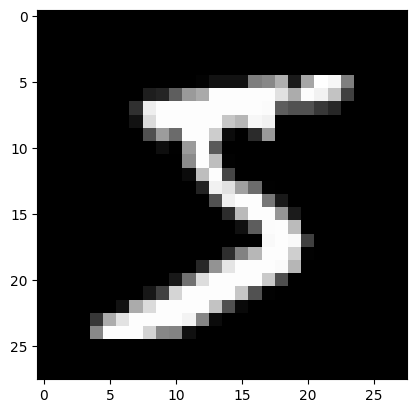

torch.Size([50000, 784])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


In [7]:
# Fetching Data
from pathlib import Path
import requests

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
        content = requests.get(URL + FILENAME).content
        (PATH / FILENAME).open("wb").write(content)

import pickle
import gzip

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
        ((X_train, y_train), (X_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

# Each image is 28 x 28, and is being stored as a flattened row of length 784 (=28x28). We need to reshape it to 2d first.

from matplotlib import pyplot
import numpy as np

pyplot.imshow(x_train[0].reshape((28, 28)), cmap="gray")
# ``pyplot.show()`` only if not on Colab
try:
    import google.colab
except ImportError:
    pyplot.show()
print(x_train.shape)

# PyTorch uses `torch.tensor`, rather than numpy arrays, so we need to convert our data.

import torch

X_train, y_train, X_valid, y_valid = map(
    torch.tensor, (X_train, y_train, X_valid, y_valid)
)
rows_count, columns_count = X_train.shape
print(X_train, y_train)
print(X_train.shape)
print(y_train.min(), y_train.max())

In [ ]:
import math

class CrapAutogradNN():
    def __init__(self):

        # Only a single layer with 784 inputs (input pixels) & 10 outputs (10 digits)
        # Basically just logistic regression ∵ no hidden layers
        self.weights = torch.randn(784, 10) / math.sqrt(784)
        self.weights.requires_grad_()
        self.bias = torch.zeros(10, requires_grad=True)
    
    def forward(self, X_batch):
        return self.log_softmax(X_batch @ self.weights + self.bias)

    def log_softmax(self, vector: torch.tensor):
        r"""
        Textbook formula:
            s(xᵢ) = exp(xᵢ) / Σ exp(xⱼ)
            → ln s(xᵢ) = xᵢ - log(Σ exp(xⱼ))
        """
        return vector - vector.exp().sum(-1).log().unsqueeze(-1) # Unsqueeze to convert back to column vector

def negative_log_likelihood(probs_input, target):
    r""""
    Textbook formula:
        P(yᵢ|xᵢ) = probability that yᵢ is the correct label for xᵢ
                 = exp(xᵢ[yᵢ]) / Σ exp(xᵢ[j])
        Log Likelihood = log P(yᵢ|xᵢ)
                       = Σ_{i=1}^{n} Σ_{c=1}^{C} y_{i,c} ln \hat{y}_{θ,i,c}
        Negative Log Likelihood = -log P(yᵢ|xᵢ)

    Input:
        input: Tensor of shape (m, 10)
        target: Tensor of shape (m,)
    Output:
        Loss: Scalar
    """
    # Refers to the probs the NN assigns to the correct classification for each example.
    # eg. for ith example in range(target.shape[0]), it finds the prob assigned to `target` (eg. 5)
    # basically the likelihood of seeing the target under the probs we 
    return -probs_input[range(target.shape[0]), target].log().mean()

def accuracy(input, y_batch):
    r"""
    Input:
        input: Tensor of shape (m, 10)
        target: Tensor of shape (m,)
    Output:
        Accuracy: Scalar
    """
    predictions = input.argmax(dim=1)
    return (predictions == y_batch).float().mean()


model = CrapAutogradNN()
print(model.forward(X_train))

batch_size = 64
X_batch = X_train[0:batch_size]
y_batch = y_train[0:batch_size]
preds = model.forward(X_batch)
print('Before training:', negative_log_likelihood(preds, y_batch), accuracy(preds, y_batch))

#from IPython.core.debugger import set_trace
def train(model, X_train, y_train, *, loss_func, batch_size, epochs=2, learning_rate=0.5):

    rows_count, columns_count = X_train.shape

    for epoch in range(epochs):
        for i in range((rows_count - 1) // batch_size + 1):
            #set_trace
            start_index = i * batch_size
            end_index   = start_index + batch_size

            X_batch = X_train[start_index:end_index]
            y_batch = y_train[start_index:end_index]

            preds = model.forward(X_batch)
            loss = loss_func(preds, y_batch)
            loss.backward()
            with torch.no_grad():
                model.weights -= model.weights.grad * learning_rate
                model.bias -= model.bias.grad * learning_rate
                model.weights.grad.zero_()
                model.bias.grad.zero_()
            

train(model, X_train, y_train, loss_func=negative_log_likelihood, batch_size=64)
preds = model.forward(X_batch)
print('After training:', negative_log_likelihood(preds, y_batch), accuracy(preds, y_batch))

tensor([[-2.3699, -2.6059, -2.3024,  ..., -2.1703, -2.3686, -2.5093],
        [-2.0058, -2.9039, -2.5866,  ..., -3.2412, -1.9478, -3.0781],
        [-2.5216, -2.1765, -2.6075,  ..., -1.9591, -2.1631, -2.8648],
        ...,
        [-2.5283, -2.1363, -2.0870,  ..., -3.0346, -2.0674, -2.4632],
        [-3.0065, -2.2870, -2.6802,  ..., -2.7017, -2.2976, -2.3697],
        [-2.3580, -1.9994, -2.2812,  ..., -2.8194, -2.4106, -2.4963]],
       grad_fn=<SubBackward0>)
Before training: tensor(2.3320, grad_fn=<MeanBackward0>) tensor(0.0781)
After training: tensor(0.2301, grad_fn=<MeanBackward0>) tensor(0.9531)


In [1]:
import torch.nn as nn

torch.manual_seed(42)
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        #self.flatten = nn.Flatten() for images
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        #x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = Net().to(device)
compiled_model = torch.compile(model)

NameError: name 'torch' is not defined